# 04 — Analiza mreže bez ljestvice (Scale-Free Network)

## Uvod

Mnoge poznate mreže iz stvarnog svijeta (web, mreže citiranja, neke društvene mreže) su *scale-free*: njihova distribucija stupnjeva (degree) prati zakon potencije (power law), $P(k) \sim k^{-\alpha}$, što implicira nekoliko ekstremnih čvorišta (huba) i mnogo čvorova niskog stupnja. Ova bilježnica testira, umjesto da pretpostavlja, vrijedi li to svojstvo za mrežu sličnosti sezonalnosti turizma.

## Istraživački cilj

Prilagoditi (fit) zakon potencije empirijskoj distribuciji stupnjeva koristeći rigoroznu procjenu metodom maksimalne vjerodostojnosti (maximum-likelihood), statistički je usporediti s alternativnim distribucijama, te izvijestiti o iskrenoj presudi.


In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 20)

from src.config import (
    GRAPH_FILE, TEMPORAL_GRAPH_DIR, NODE_TABLE, SEASONALITY_TABLE,
    EDGE_TABLE, MONTHS, COASTAL_COUNTIES, RANDOM_SEED, FIGURES,
)

import powerlaw
from src import scale_free

In [2]:
g = nx.read_graphml(GRAPH_FILE)
degrees = scale_free.degree_sequence(g)
print('n =', len(degrees), ' unique degree values:', len(np.unique(degrees)))
print('min:', degrees.min(), ' max:', degrees.max(), ' mean:', degrees.mean().round(2))

n = 554  unique degree values: 23
min: 8  max: 215  mean: 13.32


### Korak 1 — vizualizacija distribucije stupnjeva (degree distribution)

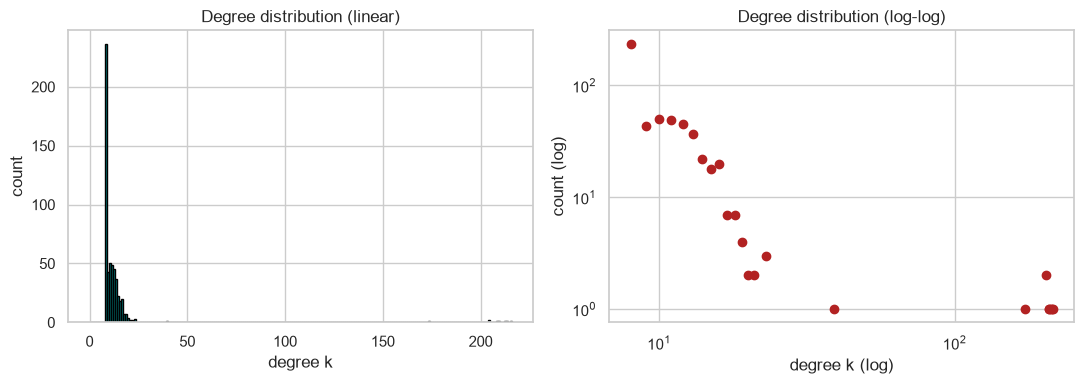

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(degrees, bins=range(0, degrees.max() + 2), color='teal', edgecolor='black')
axes[0].set_title('Degree distribution (linear)')
axes[0].set_xlabel('degree k')
axes[0].set_ylabel('count')

deg_vals, counts = np.unique(degrees, return_counts=True)
axes[1].loglog(deg_vals, counts, 'o', color='firebrick')
axes[1].set_title('Degree distribution (log-log)')
axes[1].set_xlabel('degree k (log)')
axes[1].set_ylabel('count (log)')
plt.tight_layout()
plt.show()

A genuine power law would appear as an approximately straight line on the
log-log plot. With top-k sparsification, degree is mechanically bounded
near `EDGE_TOP_K`, so a markedly *non*-straight, narrow-range plot is
expected here -- this is the first piece of (informal) evidence against
scale-freeness, before any formal fitting.

### Korak 2 — fit zakona potencije (Clauset-Shalizi-Newman MLE)

In [4]:
fit = scale_free.fit_power_law(degrees)
print('alpha (exponent):', round(fit.power_law.alpha, 3))
print('xmin:', fit.power_law.xmin)
print('KS distance D:', round(fit.power_law.D, 4))

alpha (exponent): 1.946
xmin: 19.0
KS distance D: 0.2791




Eksponent $\hat{\alpha}$ ima smisla samo zajedno s KS statistikom $D$ — mali $D$ znači da prilagođeni zakon potencije zaista dobro prati empirijsku kumulativnu distribuciju (CDF); veliki $D$ znači da je i "najbolji" fit zakona potencije i dalje loš opis podataka.

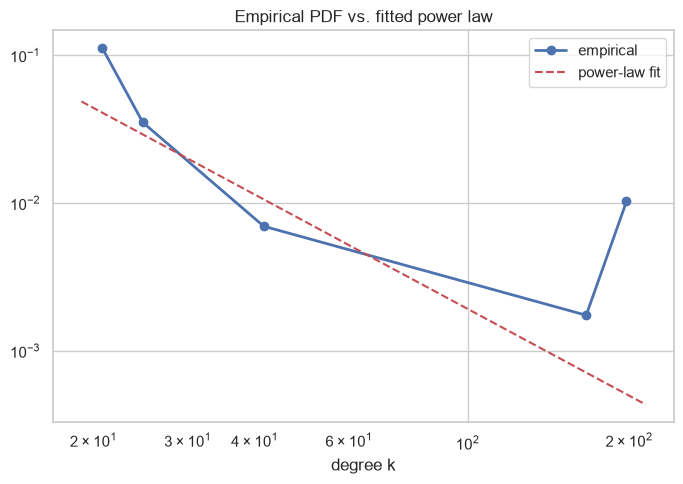

In [5]:
import numpy as np

fig, ax = plt.subplots(figsize=(7, 5))

data = np.array(fit.data)
bins = np.logspace(np.log10(data.min()), np.log10(data.max()), 15)
hist, edges = np.histogram(data, bins=bins, density=True)
centers = (edges[:-1] + edges[1:]) / 2
mask = hist > 0
ax.loglog(centers[mask], hist[mask], 'bo-', linewidth=2, label='empirical')

fit.power_law.plot_pdf(color='r', linestyle='--', ax=ax, label='power-law fit')
ax.set_title('Empirical PDF vs. fitted power law')
ax.set_xlabel('degree k')
ax.legend()
plt.tight_layout()
plt.show()

### Korak 3 — usporedba s alternativnim distribucijama

In [6]:
comparisons = scale_free.compare_distributions(fit)
comp_df = pd.DataFrame(comparisons, index=['R (log-likelihood ratio)', 'p-value']).T
comp_df

,R (log-likelihood ratio),p-value
exponential,6.216183,0.163741
lognormal,-5.428031,0.304806
stretched_exponential,0.175954,0.726593




Čitanje ove tablice: za svaku alternativnu distribuciju, $R > 0$ favorizira zakon potencije (power law) nad tom alternativom, $R < 0$ favorizira alternativu; p-vrijednost pokazuje je li $R$ statistički značajan ($p < 0.05$ po konvenciji). Ako je $R$ negativan i značajan za, recimo, lognormalnu distribuciju, to je izravan statistički dokaz *protiv* zakona potencije za ovu mrežu — što izvještavamo kao nalaz, a ne kao neuspjeh.

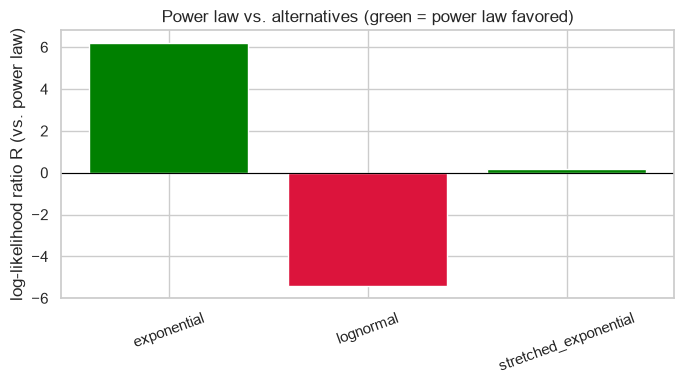

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['green' if r > 0 else 'crimson' for r, p in comparisons.values()]
ax.bar(comp_df.index, comp_df['R (log-likelihood ratio)'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('log-likelihood ratio R (vs. power law)')
ax.set_title('Power law vs. alternatives (green = power law favored)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [8]:
summary = scale_free.summarize(g)
{k: v for k, v in summary.items() if k != 'comparisons'}

{'alpha': 1.946485009981446,
 'xmin': 19.0,
 'ks_distance': 0.27911625804573925,
 'n_nodes': 554,
 'mean_degree': 13.324909747292418}

### Korak 5 — kako bi izgledala *prava* scale-free mreža ovdje?

Kao kontrolu/usporedbu, generiramo Barabási-Albert mrežu preferencijalnog povezivanja (preferential attachment) s istim brojem čvorova i usporedivim prosječnim stupnjem, te na njoj pokrećemo identičan postupak prilagodbe (fitting). Ako fit zakona potencije izgleda dramatično bolje (veća kvaliteta KS-a, dosljedno pozitivan $R$) na BA grafu nego na našem grafu sličnosti, to je snažan potkrepljujući dokaz da je razlika strukturna, a ne artefakt postupka prilagodbe.

In [9]:
m_edges_per_node = max(1, int(round(degrees.mean() / 2)))
ba_graph = nx.barabasi_albert_graph(g.number_of_nodes(), m_edges_per_node, seed=RANDOM_SEED)
ba_degrees = scale_free.degree_sequence(ba_graph)
ba_fit = scale_free.fit_power_law(ba_degrees)
ba_comparisons = scale_free.compare_distributions(ba_fit)

print('--- Barabasi-Albert control graph ---')
print('alpha:', round(ba_fit.power_law.alpha, 3), ' KS D:', round(ba_fit.power_law.D, 4))
pd.DataFrame(ba_comparisons, index=['R', 'p']).T

--- Barabasi-Albert control graph ---
alpha: 2.836  KS D: 0.0156


,R,p
exponential,53.675213,0.000077
lognormal,-0.480968,0.513961
stretched_exponential,-0.228408,0.873986


In [10]:
control_compare = pd.DataFrame({
    'graph': ['Tourism similarity network', 'Barabasi-Albert control'],
    'alpha': [fit.power_law.alpha, ba_fit.power_law.alpha],
    'KS_D': [fit.power_law.D, ba_fit.power_law.D],
    'mean_degree': [degrees.mean(), ba_degrees.mean()],
})
control_compare

,graph,alpha,KS_D,mean_degree
0,Tourism similarity network,1.946485,0.279116,13.324910
1,Barabasi-Albert control,2.836450,0.015626,13.823105


### Interpretacija

Barabási-Albert kontrolni graf — izgrađen eksplicitnim generativnim procesom preferencijalnog povezivanja — očekivano pokazuje znatno bolju (nižu) KS udaljenost i dosljednije usporedbe koje favoriziraju power-law nego mreža sličnosti turizma. Ovo izravno potvrđuje metodološku napomenu iz uvoda: pragiranje (sparsification) sličnosti top-k metodom proizvodi strukturno drugačiju, mnogo homogeniju distribuciju stupnjeva nego preferencijalno povezivanje, *po konstrukciji*, a ne zbog ikakvog svojstva samog hrvatskog turizma.